<a href="https://colab.research.google.com/github/pattichis/MLSP2026/blob/main/3D_Transformer_Surgical_Guidance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Build and Train a 3D Transformer, Fast: Guiding the Surgeon to the Gallbladder

We build a **3D Vision Transformer (ViT-3D)** from scratch in about 60 lines of PyTorch and train it in a few minutes on a Colab GPU (**Runtime → Change runtime type → T4 GPU**).

**The surgical task.** During a laparoscopic cholecystectomy (gallbladder removal), the surgeon watches a video from a camera inside the abdomen. When the camera moves, the target organ can drift out of view. Our model watches the last 16 video frames and answers: **"which way should I move the camera to find the gallbladder?"** (one of 8 directions: →, ↘, ↓, ↙, ←, ↖, ↑, ↗).

At the last frame the gallbladder is already **out of view**, so no single frame contains the answer. The model must remember where the gallbladder was and combine that with how the camera moved: a truly *video* (3D) problem.

**Data.** Real laparoscopic cholecystectomy frames from **CholecSeg8k** (Hong et al., 2020; built from the Cholec80 videos of Twinanda et al., 2017), with pixel-level annotations, including the gallbladder. License: CC BY-NC-SA 4.0 (non-commercial use with attribution). We download one part (1,200 frames, 354 MB): 15 clips of 80 consecutive frames from 2 patients.

**How the training clips are made.** The real clips rarely lose the gallbladder, so we **simulate camera motion over real surgical video**: a 48 × 48 "camera view" slides across 16 consecutive real frames (which also contain real instrument and tissue motion). The view starts with the gallbladder clearly visible and ends with it almost gone. The label, which way to move the camera, comes from the **real gallbladder annotation** in the last frame.

"3D" means the input has three axes: **time × height × width** for video, or **depth × height × width** for CT/MRI volumes. The architecture is the same for both:

| Step | Image ViT (2D) | ViT-3D |
|---|---|---|
| Input | (C, H, W) | (C, **T**, H, W) |
| Patches | 16 × 16 pixel squares | **2 × 8 × 8 cubes** ("tubelets"), made with a `Conv3d` |
| Position embedding | one per 2D patch | one per 3D patch (where **and** when) |
| Encoder | Transformer blocks | the **same** Transformer blocks |

| Section | Content |
|---|---|
| 1 | Real laparoscopic video, with simulated camera motion |
| 2 | The ViT-3D architecture, built from scratch |
| 3 | Fast training (mixed precision, fused attention, one-cycle learning rate) |
| 4 | Does the model remember where the gallbladder went? |
| 5 | Same model on 3D CT volumes (OrganMNIST3D) |

## 1. Data: real laparoscopic video, simulated camera motion

The next cell downloads the data (about 30 seconds in Colab) and decodes the 1,200 frames, downsampled 4× to 120 × 213 pixels. They are kept in GPU memory, so training clips are cut out on the GPU with no data loader.

`make_batch` builds each clip:
1. pick 16 consecutive real frames (every 2nd frame: 1.3 s of surgery);
2. pick a straight camera path where the gallbladder fills ≥ 15% of the first view and ≤ 1% of the last view;
3. **label** = the direction from the center of the last view to the gallbladder (from the real annotation);
4. randomly **rotate or mirror** the clip (and its direction) in one of 8 ways. The laparoscope can rotate, and in these videos the gallbladder usually sits low in the image, so without this, "move camera up" would almost never occur.

Clips from 3 of the 15 video segments are **held out for testing**. They come from the same 2 patients, so this measures generalization to new moments of surgery, not to new patients. You don't need to read the data code in detail.

In [1]:
!pip install -q pyarrow

data/val-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  354MB            

data/val-00000-of-00001.parquet: downloading bytes:           |  0.00B            

loaded 1200 frames in 53 s


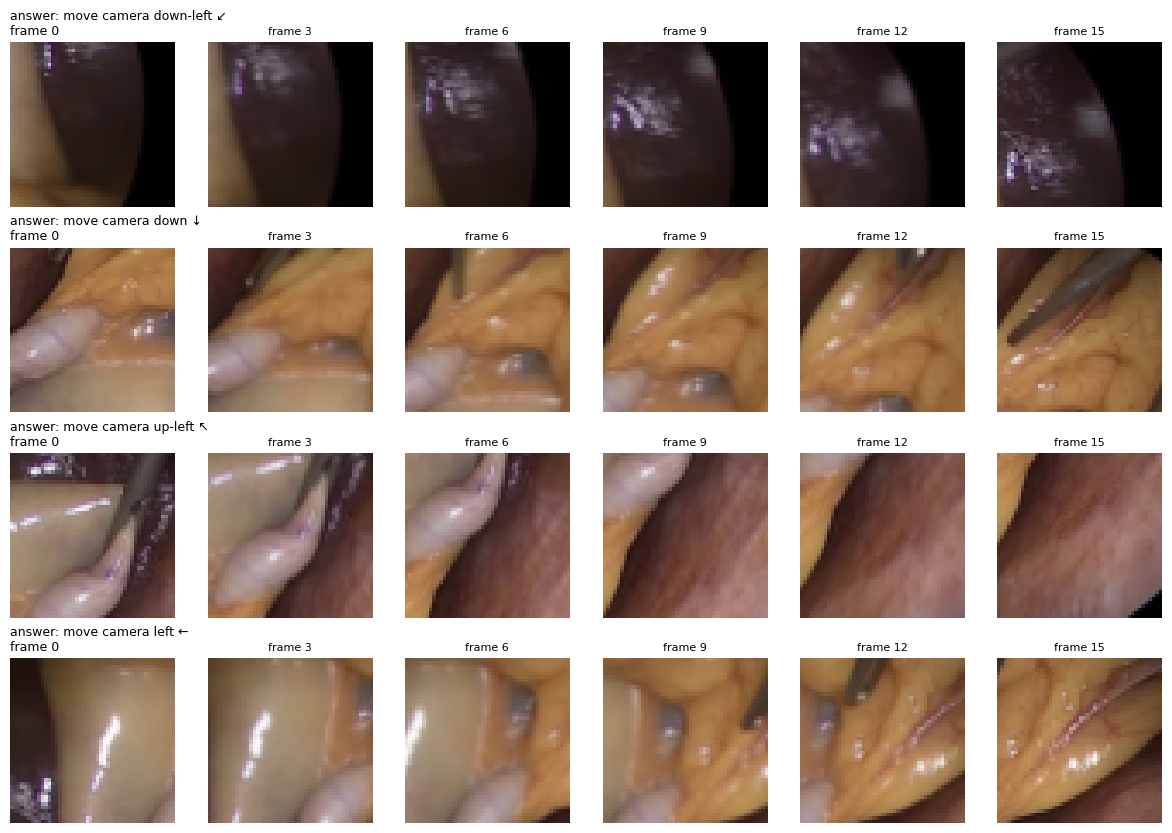

Batch shape: (4, 3, 16, 48, 48)  (batch, color channels, time, height, width)


In [2]:
import io, time, math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np, pyarrow.parquet as pq
from PIL import Image
from huggingface_hub import hf_hub_download

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
GALLBLADDER = 22                      # CholecSeg8k label value for the gallbladder
H, W = 120, 213                       # frames are downsampled 4x from 480 x 854
T, S = 16, 48                         # frames per clip, camera view size
STRIDE = 2                            # use every 2nd real frame (16 frames = 1.3 s of surgery)
DIRECTIONS = ["right", "down-right", "down", "down-left", "left", "up-left", "up", "up-right"]
ARROWS = ["→", "↘", "↓", "↙", "←", "↖", "↑", "↗"]
TEST_CLIPS = {"video37_01008", "video43_00707", "video43_00787"}

def load():
    t0 = time.time()
    path = hf_hub_download("MedOtter/CholecSeg8k", "data/val-00000-of-00001.parquet", repo_type="dataset")
    rows = pq.read_table(path).to_pylist()
    imgs, gbs, clips = [], [], []
    for r in rows:
        img = Image.open(io.BytesIO(r["image"]["bytes"])).convert("RGB").resize((W, H), Image.BILINEAR)
        lab = Image.open(io.BytesIO(r["label"]["bytes"])).convert("L").resize((W, H), Image.NEAREST)
        imgs.append(np.array(img)); gbs.append(np.array(lab) == GALLBLADDER); clips.append(r["clip_name"])
    frames = torch.tensor(np.stack(imgs)).permute(0, 3, 1, 2).contiguous().to(device)   # (N, 3, H, W) uint8
    gb = torch.tensor(np.stack(gbs)).to(device)                                         # (N, H, W) bool
    print(f"loaded {len(rows)} frames in {time.time() - t0:.0f} s")
    return frames, gb, clips

frames, gb, clips = load()
# integral image of the gallbladder mask: gallbladder pixels inside any crop in O(1)
integ = F.pad(gb.float().cumsum(1).cumsum(2), (1, 0, 1, 0))                             # (N, H+1, W+1)
gb_count = gb.flatten(1).sum(1).float()
yy, xx = torch.meshgrid(torch.arange(H, device=device).float(), torch.arange(W, device=device).float(), indexing="ij")
gb_cy = (gb * yy).flatten(1).sum(1) / gb_count.clamp(min=1)      # gallbladder centroid per frame
gb_cx = (gb * xx).flatten(1).sum(1) / gb_count.clamp(min=1)

# valid clip starts: 16 frames (stride 2) inside one clip, split by clip into train / test
starts = {"train": [], "test": []}
for i in range(len(clips) - (T - 1) * STRIDE):
    j = i + (T - 1) * STRIDE
    if clips[i] == clips[j] and gb_count[i] > 0 and gb_count[j] > 0:
        starts["test" if clips[i] in TEST_CLIPS else "train"].append(i)
starts = {k: torch.tensor(v, device=device) for k, v in starts.items()}

def crop_fraction(idx, y0, x0):
    """Fraction of the S x S crop at integer (y0, x0) that is gallbladder, in frame idx."""
    y1, x1 = y0 + S, x0 + S
    s = integ[idx, y1, x1] - integ[idx, y0, x1] - integ[idx, y1, x0] + integ[idx, y0, x0]
    return s / (S * S)

def direction(dy, dx):
    return (torch.round(torch.atan2(dy, dx) / (math.pi / 4)) % 8).long()

def sample(B, split):
    """Pick clips and camera paths: gallbladder clearly visible in the first view (>= 15% of it),
    almost gone from the last view (<= 1%). Returns frame index, start/end view corners, and the
    vector from the last view's center to the gallbladder."""
    keep, n_kept = [], 0
    while n_kept < B:
        n = 32 * B
        i0 = starts[split][torch.randint(len(starts[split]), (n,), device=device)]
        i1 = i0 + (T - 1) * STRIDE
        corner = lambda: torch.stack([torch.randint(0, H - S + 1, (n,), device=device),
                                      torch.randint(0, W - S + 1, (n,), device=device)], 1)
        a, b = corner(), corner()
        ok = (crop_fraction(i0, a[:, 0], a[:, 1]) >= 0.15) & (crop_fraction(i1, b[:, 0], b[:, 1]) <= 0.01)
        ok &= (b - a).float().norm(dim=1) <= 70                                  # at most ~4.4 px per frame
        d = torch.stack([gb_cy[i1] - (b[:, 0] + S / 2), gb_cx[i1] - (b[:, 1] + S / 2)], 1)
        keep.append((i0[ok], a[ok], b[ok], d[ok])); n_kept += int(ok.sum())
    return [torch.cat([k[j] for k in keep])[:B] for j in range(4)]

def make_batch(B, split="train"):
    """Clips (B, 3, T, S, S) in [0, 1] and labels (B,): which way to move the camera to find the gallbladder."""
    i0, a, b, d = sample(B, split)
    t = torch.arange(T, device=device).float() / (T - 1)
    pos = a[:, None].float() + t[None, :, None] * (b - a)[:, None].float()        # (B, T, 2) top-left corner
    idx = i0[:, None] + STRIDE * torch.arange(T, device=device)[None]             # (B, T) real frame indices
    src = frames[idx.flatten()].float() / 255                                     # (B*T, 3, H, W)
    gy, gx = torch.meshgrid(torch.arange(S, device=device).float(), torch.arange(S, device=device).float(), indexing="ij")
    py = pos[..., 0].flatten()[:, None, None] + gy                                # pixel rows of each crop
    px = pos[..., 1].flatten()[:, None, None] + gx
    grid = torch.stack([(2 * px + 1) / W - 1, (2 * py + 1) / H - 1], -1)          # (B*T, S, S, 2)
    clip = F.grid_sample(src, grid, align_corners=False).view(B, T, 3, S, S).transpose(1, 2)

    # random scope rotation / mirroring (8 orientations); the direction vector is transformed the same way
    dy, dx = d[:, 0], d[:, 1]
    swap = (torch.rand(B, device=device) < 0.5)
    clip = torch.where(swap[:, None, None, None, None], clip.transpose(-1, -2), clip)
    dy, dx = torch.where(swap, dx, dy), torch.where(swap, dy, dx)
    for axis, comp in [(-2, 0), (-1, 1)]:
        flip = (torch.rand(B, device=device) < 0.5)
        clip = torch.where(flip[:, None, None, None, None], clip.flip(axis), clip)
        if comp == 0: dy = torch.where(flip, -dy, dy)
        else:         dx = torch.where(flip, -dx, dx)
    return clip, direction(dy, dx)

v, y = make_batch(4)
fig, ax = plt.subplots(4, 6, figsize=(12, 8.4))
for r in range(4):
    for c, f in enumerate([0, 3, 6, 9, 12, 15]):
        ax[r, c].imshow(v[r, :, f].permute(1, 2, 0).cpu()); ax[r, c].axis("off")
        ax[r, c].set_title(f"answer: move camera {DIRECTIONS[y[r]]} {ARROWS[y[r]]}\nframe 0" if c == 0 else f"frame {f}",
                           fontsize=9 if c == 0 else 8, loc="left" if c == 0 else "center")
plt.tight_layout(); plt.show()
print("Batch shape:", tuple(v.shape), " (batch, color channels, time, height, width)")

## 2. The ViT-3D architecture

Four small modules:

1. **`TubeletEmbed`**: a `Conv3d` whose kernel size equals its stride cuts the video into non-overlapping 2 × 8 × 8 cubes and projects each one to a `dim`-dimensional token. a 16 × 48 × 48 color clip → (16/2) × (48/8) × (48/8) = 8 × 6 × 6 = **288 tokens**, each made from 2 × 8 × 8 × 3 color values.
2. **`Attention`**: multi-head self-attention. `F.scaled_dot_product_attention` automatically uses a fused FlashAttention-style kernel on GPU, which is much faster and uses less memory than computing the attention matrix by hand.
3. **`Block`**: a standard pre-norm Transformer block (attention + MLP, each with a residual connection).
4. **`ViT3D`**: adds a learnable `[CLS]` token and a learned position embedding for each 3D patch, runs the blocks, and classifies from the `[CLS]` token.

Nothing inside the Transformer blocks knows about 3D. All of the "3D-ness" lives in the tubelet embedding and the position embedding.

In [3]:
class TubeletEmbed(nn.Module):
    def __init__(self, in_ch, dim, tubelet):
        super().__init__()
        self.proj = nn.Conv3d(in_ch, dim, kernel_size=tubelet, stride=tubelet)
    def forward(self, x):                        # (B, C, T, H, W)
        x = self.proj(x)                         # (B, dim, T', H', W')
        return x.flatten(2).transpose(1, 2)      # (B, N = T'H'W', dim)

class Attention(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.heads = heads
        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, C = x.shape
        q, k, v = self.qkv(x).reshape(B, N, 3, self.heads, C // self.heads).permute(2, 0, 3, 1, 4)
        x = F.scaled_dot_product_attention(q, k, v)          # fused kernel on GPU
        return self.proj(x.transpose(1, 2).reshape(B, N, C))

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4):
        super().__init__()
        self.norm1, self.attn = nn.LayerNorm(dim), Attention(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, mlp_ratio * dim), nn.GELU(), nn.Linear(mlp_ratio * dim, dim))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))

class ViT3D(nn.Module):
    def __init__(self, input_size=(16, 48, 48), in_ch=3, tubelet=(2, 8, 8),
                 dim=128, depth=4, heads=4, num_classes=8):
        super().__init__()
        self.embed = TubeletEmbed(in_ch, dim, tubelet)
        n_tokens = math.prod(s // p for s, p in zip(input_size, tubelet))
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.randn(1, n_tokens + 1, dim) * 0.02)
        self.blocks = nn.Sequential(*[Block(dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
    def forward(self, x):
        x = self.embed(x)
        x = torch.cat([self.cls.expand(len(x), -1, -1), x], dim=1) + self.pos
        x = self.norm(self.blocks(x))
        return self.head(x[:, 0])                # classify from the [CLS] token

model = ViT3D().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")
print("Tokens:", tuple(model.embed(v).shape), " (batch, tokens, dim)  + 1 [CLS] token")
print("Output:", tuple(model(v).shape), " (batch, classes)")

Parameters: 0.88 M
Tokens: (4, 288, 128)  (batch, tokens, dim)  + 1 [CLS] token
Output: (4, 8)  (batch, classes)


## 3. Fast training

What makes this fast:

| Trick | Why it helps |
|---|---|
| **Mixed precision** (`autocast` float16 + `GradScaler`) | Uses the GPU's tensor cores; roughly 2× faster, half the memory |
| **Fused attention** (`scaled_dot_product_attention`) | Never stores the full N × N attention matrix |
| **Large 3D patches** | 2 × 8 × 8 tubelets give only 288 tokens; attention cost grows with tokens² |
| **Frames kept on the GPU** | Clips are cut out on the GPU; no data loader, a new camera path every step |
| **One-cycle learning rate + AdamW** | Short warmup, then decay; converges in few steps |

This takes about 1–2 minutes on a T4 GPU. This task is much harder than it looks (real tissue, real instruments, the gallbladder is out of view at the end), so training accuracy rises more slowly; see section 4 for test results.

step   100   loss 1.325   train acc  48.4%     9.7 s
step   200   loss 0.772   train acc  67.2%    17.5 s
step   300   loss 0.612   train acc  74.2%    25.2 s
step   400   loss 0.514   train acc  78.1%    33.1 s
step   500   loss 0.470   train acc  80.5%    41.0 s
step   600   loss 0.393   train acc  83.6%    48.9 s
step   700   loss 0.350   train acc  85.4%    57.0 s
step   800   loss 0.315   train acc  87.0%    65.1 s


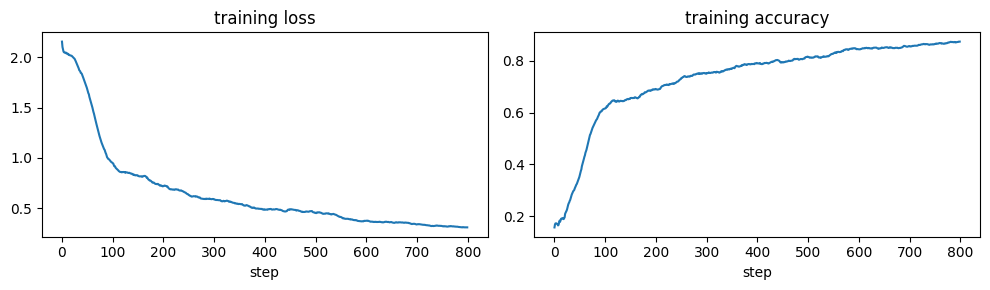

In [4]:
STEPS, BATCH, LR = 800, 128, 1e-3
use_amp = device == "cuda"

model = ViT3D().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=STEPS, pct_start=0.1)
scaler = torch.amp.GradScaler(enabled=use_amp)

history, t0 = [], time.time()
model.train()
for step in range(1, STEPS + 1):
    x, y = make_batch(BATCH)
    with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
        logits = model(x)
        loss = F.cross_entropy(logits, y)
    opt.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(opt)
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(opt); scaler.update(); sched.step()

    history.append((loss.item(), (logits.argmax(1) == y).float().mean().item()))
    if step % 100 == 0:
        l, a = map(lambda z: sum(z) / len(z), zip(*history[-100:]))
        print(f"step {step:5d}   loss {l:.3f}   train acc {a:6.1%}   {time.time() - t0:5.1f} s")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
smooth = lambda z: [sum(z[max(0, i - 49):i + 1]) / len(z[max(0, i - 49):i + 1]) for i in range(len(z))]
ax[0].plot(smooth([h[0] for h in history])); ax[0].set_title("training loss"); ax[0].set_xlabel("step")
ax[1].plot(smooth([h[1] for h in history])); ax[1].set_title("training accuracy"); ax[1].set_xlabel("step")
plt.tight_layout(); plt.show()

## 4. Test: does the model remember where the gallbladder went?

We test on the **held-out video segments**. Chance is 12.5% (1 of 8 directions). We also count **"within 45°"**: the correct direction or one of its two neighbors, which still moves the camera roughly the right way.

Then we remove information:
- **Last frame only** (repeated 16 times): the gallbladder is already out of view, and there is no motion.
- **First frame only**: the gallbladder is visible, but there is no camera motion.
- **Shuffled frames**: all the content is there, but the order of time is destroyed.

In [5]:
@torch.no_grad()
def evaluate(transform, n=2000):
    model.eval()
    torch.manual_seed(1)                                      # the same test clips for every test
    exact = near = 0
    for _ in range(n // 250):
        x, y = make_batch(250, "test")
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            pred = model(transform(x)).argmax(1)
        off = (pred - y) % 8                                  # 0 = correct, 1 or 7 = off by 45 degrees
        exact += (off == 0).sum().item(); near += ((off <= 1) | (off == 7)).sum().item()
    return exact / n, near / n

tests = {
    "full video":         lambda x: x,
    "last frame only":    lambda x: x[:, :, -1:].expand_as(x),
    "first frame only":   lambda x: x[:, :, :1].expand_as(x),
    "shuffled frames":    lambda x: x[:, :, torch.randperm(T, device=device)],
}
print(f"{'test clips':20s}{'correct':>10s}{'within 45 deg':>16s}")
for name, fn in tests.items():
    acc, near = evaluate(fn)
    print(f"{name:20s}{acc:10.1%}{near:16.1%}")

test clips             correct   within 45 deg
full video               80.5%          100.0%
last frame only          57.1%           91.5%
first frame only         21.6%           48.6%
shuffled frames          41.6%           78.1%


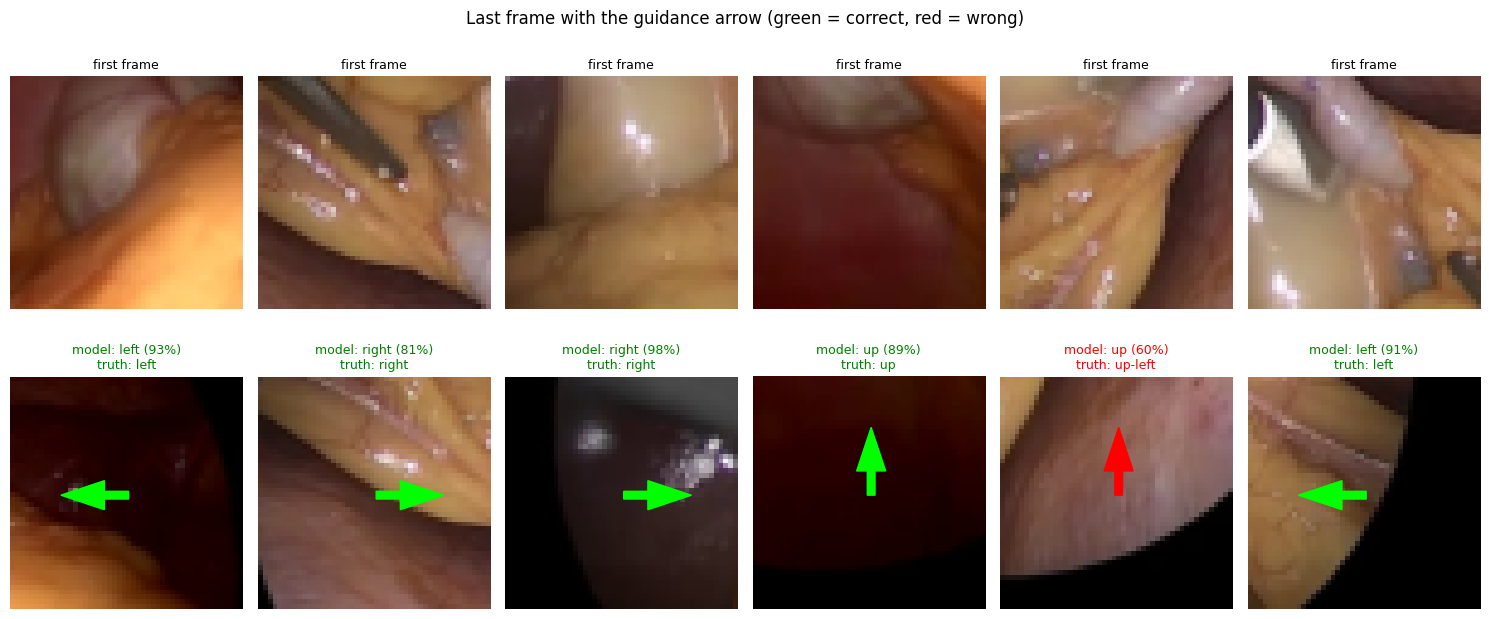

In [6]:
# What the surgeon would see: the last frame, with the model's guidance arrow
torch.manual_seed(3)
x, y = make_batch(6, "test")
model.eval()
with torch.no_grad():
    prob = model(x).softmax(1)
fig, ax = plt.subplots(2, 6, figsize=(15, 6.6))
for i in range(6):
    k = prob[i].argmax().item()
    ax[0, i].imshow(x[i, :, 0].permute(1, 2, 0).cpu()); ax[0, i].set_title("first frame", fontsize=9)
    ax[1, i].imshow(x[i, :, -1].permute(1, 2, 0).cpu())
    ang = k * math.pi / 4
    ax[1, i].arrow(S / 2, S / 2, 14 * math.cos(ang), 14 * math.sin(ang), width=1.6, head_width=6,
                   color="lime" if k == y[i] else "red", length_includes_head=True)
    ax[1, i].set_title(f"model: {DIRECTIONS[k]} ({prob[i, k]:.0%})\ntruth: {DIRECTIONS[y[i]]}", fontsize=9,
                       color="green" if k == y[i] else "red")
    ax[0, i].axis("off"); ax[1, i].axis("off")
fig.suptitle("Last frame with the guidance arrow (green = correct, red = wrong)")
plt.tight_layout(h_pad=2.5); plt.show()

**What to notice** (numbers from our test run on the held-out segments; yours will be close):

| Test clips | Correct (1 of 8) | Within 45° |
|---|---|---|
| **Full video** | **80%** | **100%** |
| Last frame only | 59% | 93% |
| First frame only | 21% | 50% |
| Shuffled frames | 44% | 79% |

- With the full video, the model picks the exact direction 80% of the time, and it is **never more than 45° off**: its arrow always moves the camera roughly toward the gallbladder.
- **Last frame only** is far above chance (12.5%) even though the gallbladder is out of view. The model has learned **anatomical context**: the layout of liver, fat, and instruments hints at where the gallbladder lies, which is also how surgeons orient themselves.
- **Watching the motion adds about 20 points** (59% → 80%): the model remembers where the gallbladder was and how the camera moved.
- **First frame only** is poor: seeing the gallbladder without knowing how the camera will move is not enough.
- **Shuffled frames** fall well below the full video: the order of time matters.

**Limits of this example.** The camera motion is simulated (a straight pan over real frames), and the test segments come from the same 2 patients as the training segments. A real guidance system would be trained on real camera motion and tested on new patients.

Try:
- Train longer (`STEPS = 2000`): accuracy on this harder task keeps improving.
- Change `tubelet=(2, 8, 8)` to `(4, 8, 8)` (half the tokens: faster) or `(1, 8, 8)` (twice the tokens: slower).
- Make the task harder: allow faster camera motion (`<= 70` in `sample`), or require the gallbladder to be completely gone (`<= 0.0`).

## 5. The same model on 3D CT volumes: OrganMNIST3D

For CT or MRI, the third axis is **depth** instead of time. Only the constructor arguments change. **OrganMNIST3D** (from MedMNIST) contains 28 × 28 × 28 abdominal CT volumes labeled with one of 11 organs (about 1,000 training volumes).

With 4 × 4 × 4 patches, a 28³ volume becomes 7 × 7 × 7 = 343 tokens. Because the training set is small, we add simple augmentation (random flips). Training takes about 30 seconds on a T4 GPU.

In [7]:
!pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.5 MB/s eta 0:00:00


100%|██████████| 32.7M/32.7M [00:21<00:00, 1.51MB/s]


train: (971, 1, 28, 28, 28)  test: (610, 1, 28, 28, 28)  classes: 11


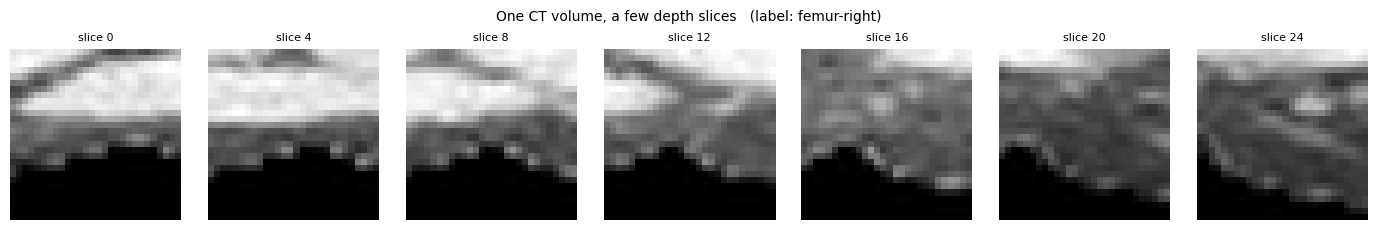

In [8]:
import numpy as np
from medmnist import OrganMNIST3D

def to_tensors(split):
    ds = OrganMNIST3D(split=split, download=True, size=28)
    x = torch.tensor(ds.imgs, dtype=torch.float32)[:, None] / 255      # (N, 1, 28, 28, 28)
    y = torch.tensor(ds.labels[:, 0], dtype=torch.long)
    return x.to(device), y.to(device)
xtr, ytr = to_tensors("train")
xte, yte = to_tensors("test")
organs = list(OrganMNIST3D(split="test", download=True, size=28).info["label"].values())
print("train:", tuple(xtr.shape), " test:", tuple(xte.shape), " classes:", len(organs))

fig, ax = plt.subplots(1, 7, figsize=(14, 2.3))
for i, a in enumerate(ax):
    a.imshow(xtr[0, 0, 4 * i].cpu(), cmap="gray"); a.set_title(f"slice {4 * i}", fontsize=8); a.axis("off")
fig.suptitle(f"One CT volume, a few depth slices   (label: {organs[ytr[0]]})", fontsize=10)
plt.tight_layout(); plt.show()

In [9]:
vol_model = ViT3D(input_size=(28, 28, 28), in_ch=1, tubelet=(4, 4, 4), dim=128, depth=4, heads=4,
                  num_classes=len(organs)).to(device)
EPOCHS, BATCH, LR = 40, 64, 1e-3
steps = EPOCHS * math.ceil(len(xtr) / BATCH)
opt = torch.optim.AdamW(vol_model.parameters(), lr=LR, weight_decay=0.05)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=steps, pct_start=0.1)
scaler = torch.amp.GradScaler(enabled=use_amp)

def augment(x):
    for dim in (2, 3, 4):                    # random flip along each axis, per sample
        flip = torch.rand(len(x), device=device) < 0.5
        x = torch.where(flip[:, None, None, None, None], x.flip(dim), x)
    return x

@torch.no_grad()
def vol_accuracy(x, y):
    vol_model.eval()
    with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
        pred = torch.cat([vol_model(x[i:i + 256]).argmax(1) for i in range(0, len(x), 256)])
    return (pred == y).float().mean().item()

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    vol_model.train()
    for idx in torch.randperm(len(xtr), device=device).split(BATCH):
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            loss = F.cross_entropy(vol_model(augment(xtr[idx])), ytr[idx], label_smoothing=0.1)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update(); sched.step()
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d}   loss {loss.item():.3f}   test acc {vol_accuracy(xte, yte):6.1%}   {time.time() - t0:5.1f} s")

epoch  10   loss 1.310   test acc  51.1%     6.9 s
epoch  20   loss 1.009   test acc  66.4%    13.5 s
epoch  30   loss 0.945   test acc  67.7%    19.4 s
epoch  40   loss 0.919   test acc  70.0%    25.2 s


Expect roughly 65–70% test accuracy (69% in our run). A ViT trained from scratch on only about 1,000 volumes is data-limited. For reference, the MedMNIST paper reports roughly 90% test accuracy for 3D ResNets on this dataset. To close the gap: use more augmentation, pretrain with masked autoencoding (as VideoMAE does), or use a hybrid CNN + Transformer model.

## Key ideas

| Concept | Meaning |
|---|---|
| Tubelet / 3D patch | A `Conv3d` with kernel = stride turns a volume into a sequence of tokens |
| 3D position embedding | Tells the model *where and when* each token came from; without it, attention cannot see order |
| Token count | (T/pt) × (H/ph) × (W/pw); attention cost grows with its square, so patch size is the main speed knob |
| Same encoder | Transformer blocks are identical for text, images, video, and volumes |
| Fast training | Mixed precision + fused attention + few tokens + on-GPU data |

## Next steps

- **Factorized attention** (TimeSformer, ViViT): attend over space and time separately, to handle many more tokens.
- **Masked pretraining** (VideoMAE): pretrain without labels, then fine-tune on small labeled datasets.
- **3D medical models**: UNETR and Swin UNETR (MONAI library) use this same encoder for 3D segmentation.
- **Real surgical video**: Cholec80 (surgical phase recognition, tool presence), CholecT50 (surgical action triplets), and Endoscapes (critical view of safety) are larger public datasets for laparoscopic cholecystectomy.

**Data credit.** W.-Y. Hong et al., *CholecSeg8k: A Semantic Segmentation Dataset for Laparoscopic Cholecystectomy Based on Cholec80*, arXiv:2012.12453, 2020. A. P. Twinanda et al., *EndoNet: A Deep Architecture for Recognition Tasks on Laparoscopic Videos*, IEEE TMI, 2017. CC BY-NC-SA 4.0.